# 00 - smoke pair run

Run the current `volume_weighted_breakout` strategy on a small pair of assets. This is a pipeline smoke test: it uses the canonical harness, does not create iteration artifacts, and does not touch holdout.

In [1]:
import sys; sys.path.insert(0, ".")   # cwd = notebooks/volume_weighted_breakout
from _lab import *

symbols = ["BTCUSDT", "ETHUSDT"]
start, end = "2024-01-01", "2024-07-01"

print("strategy:", strategy.__name__)
print("default TF:", strategy.DEFAULT_TF)
print("default symbols:", strategy.DEFAULT_SYMBOLS)
for sym in symbols:
    print(f"{sym} coverage:", coverage(sym))

strategy: strategy_volume_weighted_breakout
default TF: 4h
default symbols: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT']
BTCUSDT coverage: ('2024-01', '2026-05', 29)
ETHUSDT coverage: ('2024-01', '2026-05', 29)


In [2]:
data = load_pair_data(symbols, start, end)
for sym, df in data.items():
    print(f"{sym}: rows={len(df)} from {df.index[0]} to {df.index[-1]}")
data[symbols[0]].head()

BTCUSDT: rows=1092 from 2024-01-01 00:00:00+00:00 to 2024-06-30 20:00:00+00:00
ETHUSDT: rows=1092 from 2024-01-01 00:00:00+00:00 to 2024-06-30 20:00:00+00:00


,open,high,low,close,volume
timestamp,,,,,
2024-01-01 00:00:00+00:00,42324.8,42842.9,42271.5,42384.1,11497.162
2024-01-01 04:00:00+00:00,42384.1,42533.0,42211.2,42531.7,6040.870
2024-01-01 08:00:00+00:00,42531.7,42809.6,42492.7,42735.1,7555.517
2024-01-01 12:00:00+00:00,42735.1,42890.0,42605.4,42825.1,7622.312
2024-01-01 16:00:00+00:00,42825.1,43604.0,42707.1,43570.1,17445.176


In [3]:
signals = generate_pair_signals(symbols, start, end)
pos = positions_wide(signals)

print(f"signal rows={len(signals)}")
print("non-flat bars by symbol:")
print((pos != 0).sum())
pos.tail()

signal rows=2184
non-flat bars by symbol:
symbol
BTCUSDT    111
ETHUSDT     90
dtype: int64


symbol,BTCUSDT,ETHUSDT
timestamp,,
2024-06-30 04:00:00+00:00,0.0,0.0
2024-06-30 08:00:00+00:00,0.0,0.0
2024-06-30 12:00:00+00:00,0.0,0.0
2024-06-30 16:00:00+00:00,0.0,0.0
2024-06-30 20:00:00+00:00,0.0,0.0


In [4]:
result = run_pair(symbols, start, end)
metrics_frame(result)

,sharpe,sortino,max_dd,total_return,n_trades,pct_time_in_position,profit_factor
split,,,,,,,
train,-0.062859,-0.038465,0.062721,-0.006184,27,13.919414,0.974601
oos,-3.390748,-2.078016,0.054250,-0.043632,11,19.780220,0.334357


[saved] notebooks\volume_weighted_breakout\_out\00_smoke_pair_run.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/00_smoke_pair_run.png')

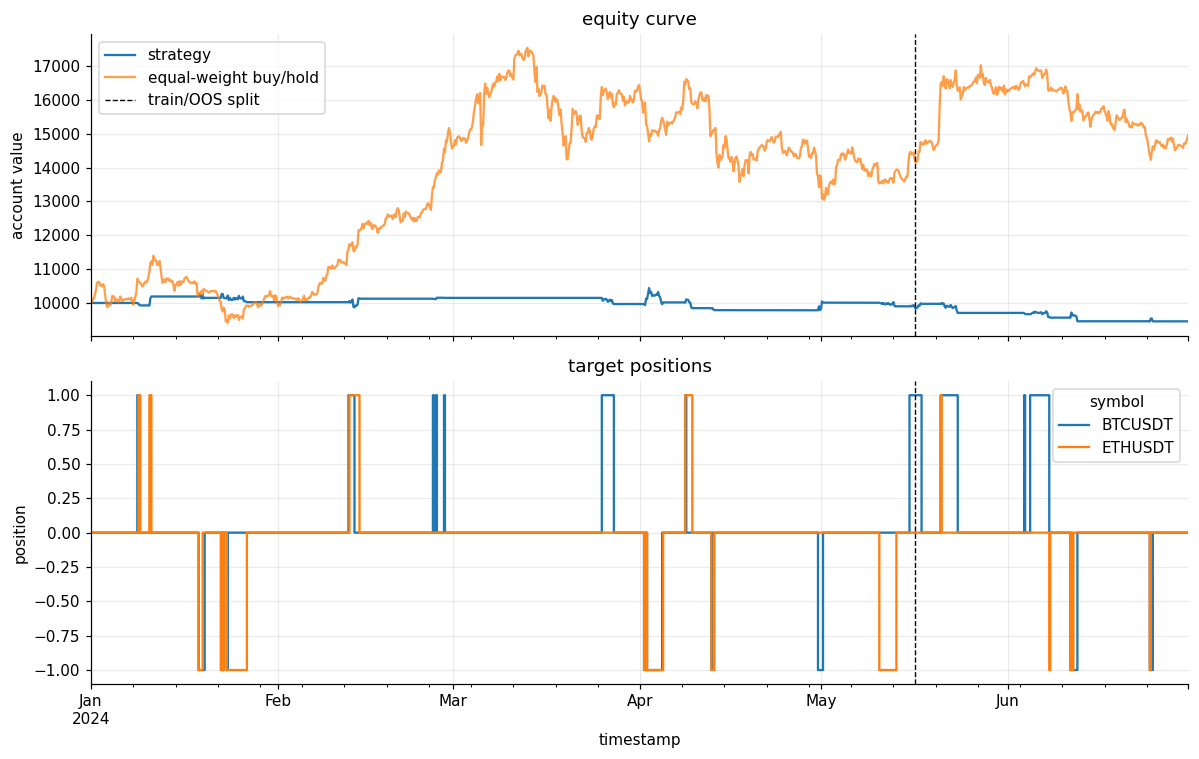

In [5]:
curves = result["curves"]
equity = curves["equity"]
bench = curves["benchmark"]
cutoff = curves["split_cutoff"]

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
equity.plot(ax=ax[0], label="strategy")
bench.plot(ax=ax[0], label="equal-weight buy/hold", alpha=0.75)
ax[0].axvline(cutoff, color="k", lw=0.9, ls="--", label="train/OOS split")
ax[0].set_title("equity curve")
ax[0].set_ylabel("account value")
ax[0].legend()

pos.reindex(equity.index).ffill().fillna(0.0).plot(ax=ax[1], drawstyle="steps-post")
ax[1].axvline(cutoff, color="k", lw=0.9, ls="--")
ax[1].set_title("target positions")
ax[1].set_ylabel("position")

show("00_smoke_pair_run")

If the metric table printed and `_out/00_smoke_pair_run.png` was saved, the notebook pipeline can run the strategy on a selected asset pair.